In [10]:
import sympy as sp

# 1. Variables simbólicas
phi, theta, psi = sp.symbols('phi theta psi', real=True)

# 2. Matrices de rotación canónicas
Rz1 = sp.Matrix([
    [sp.cos(phi), -sp.sin(phi), 0],
    [sp.sin(phi),  sp.cos(phi), 0],
    [          0,            0, 1]
])

Ry = sp.Matrix([
    [ sp.cos(theta), 0, sp.sin(theta)],
    [             0, 1,             0],
    [-sp.sin(theta), 0, sp.cos(theta)]
])

Rz2 = sp.Matrix([
    [sp.cos(psi), -sp.sin(psi), 0],
    [sp.sin(psi),  sp.cos(psi), 0],
    [          0,            0, 1]
])

# Multiplicación ZYZ
R_zyz = Rz1 * Ry * Rz2

# 3. Evaluar en theta = 0 y simplificar
R_singular = sp.simplify(R_zyz.subs(theta, 0))

print("Matriz R_ZYZ cuando theta = 0:")
sp.pprint(R_singular)

# 4. Derivadas parciales respecto a phi y psi en theta = 0
dR_dphi = sp.diff(R_zyz, phi).subs(theta, 0)
dR_dpsi = sp.diff(R_zyz, psi).subs(theta, 0)

dR_dphi_simplified = sp.simplify(dR_dphi)
dR_dpsi_simplified = sp.simplify(dR_dpsi)

print("\nDerivada respecto a phi (theta=0):")
sp.pprint(dR_dphi_simplified)

print("\nDerivada respecto a psi (theta=0):")
sp.pprint(dR_dpsi_simplified)

print("\n¿Son las derivadas linealmente dependientes?:", dR_dphi_simplified == dR_dpsi_simplified)


Matriz R_ZYZ cuando theta = 0:
⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦

Derivada respecto a phi (theta=0):
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

Derivada respecto a psi (theta=0):
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦

¿Son las derivadas linealmente dependientes?: True


=== CASO 1: theta = 0.0001° ===
Matriz Evaluada R_ZYZ:
[[ 2.58819e-01 -9.65926e-01  1.00000e-06]
 [ 9.65926e-01  2.58819e-01  1.00000e-06]
 [-2.00000e-06  1.00000e-06  1.00000e+00]]
Ángulos Recuperados -> Phi: 45.0000°, Theta: 0.000100°, Psi: 30.0000°

=== CASO 2: theta = 1e-11° ===
Ángulos Recuperados -> Phi: 45.0000°, Theta: 0.000000000010°, Psi: 30.0000°



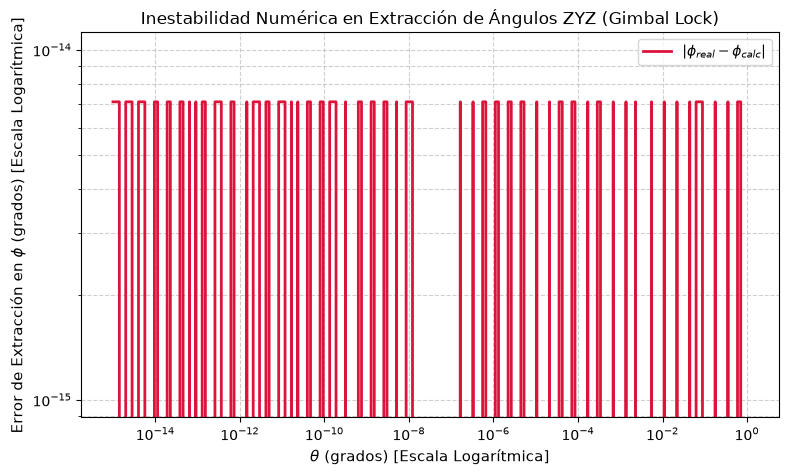

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def rot_zyz(phi_deg, theta_deg, psi_deg):
    """Calcula la matriz R_ZYZ dada la inclinación en grados."""
    phi = np.radians(phi_deg)
    theta = np.radians(theta_deg)
    psi = np.radians(psi_deg)
    
    Rz1 = np.array([
        [np.cos(phi), -np.sin(phi), 0],
        [np.sin(phi),  np.cos(phi), 0],
        [0, 0, 1]
    ])
    
    Ry = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    Rz2 = np.array([
        [np.cos(psi), -np.sin(psi), 0],
        [np.sin(psi),  np.cos(psi), 0],
        [0, 0, 1]
    ])
    
    return Rz1 @ Ry @ Rz2

def extract_zyz_angles(R):
    """Extrae los ángulos (phi, theta, psi) en grados a partir de una matriz R_ZYZ."""
    sin_theta = np.sqrt(R[0, 2]**2 + R[1, 2]**2)
    cos_theta = R[2, 2]
    
    theta = np.arctan2(sin_theta, cos_theta)
    
    # Cálculo directo usando los índices correctos para una matriz 3x3 (0, 1, 2)
    phi = np.arctan2(R[1, 2], R[0, 2])
    psi = np.arctan2(R[2, 1], -R[2, 0])
    
    return np.degrees(phi), np.degrees(theta), np.degrees(psi)

# --- 1. Caso 1: theta = 0.0001 deg ---
phi_real = 45.0
psi_real = 30.0
theta_case1 = 0.0001

R_case1 = rot_zyz(phi_real, theta_case1, psi_real)
phi_ext1, theta_ext1, psi_ext1 = extract_zyz_angles(R_case1)

print(f"=== CASO 1: theta = {theta_case1}° ===")
print("Matriz Evaluada R_ZYZ:")
print(np.round(R_case1, 6))
print(f"Ángulos Recuperados -> Phi: {phi_ext1:.4f}°, Theta: {theta_ext1:.6f}°, Psi: {psi_ext1:.4f}°\n")

# --- 2. Caso 2: theta = 0.00000000001 deg ---
theta_case2 = 1e-11
R_case2 = rot_zyz(phi_real, theta_case2, psi_real)
phi_ext2, theta_ext2, psi_ext2 = extract_zyz_angles(R_case2)

print(f"=== CASO 2: theta = {theta_case2}° ===")
print(f"Ángulos Recuperados -> Phi: {phi_ext2:.4f}°, Theta: {theta_ext2:.12f}°, Psi: {psi_ext2:.4f}°\n")

# --- 3. Análisis de Inestabilidad y Gráfica del Error ---
thetas_deg = np.logspace(-15, 0, 200) # De 10^-15 a 10^0 grados
errors_phi = []

for th in thetas_deg:
    R = rot_zyz(phi_real, th, psi_real)
    p_ext, _, _ = extract_zyz_angles(R)
    err = np.abs(phi_real - p_ext)
    errors_phi.append(err)

plt.figure(figsize=(9, 5))
plt.loglog(thetas_deg, errors_phi, color='crimson', lw=2, label=r'$|\phi_{real} - \phi_{calc}|$')
plt.title("Inestabilidad Numérica en Extracción de Ángulos ZYZ (Gimbal Lock)", fontsize=12)
plt.xlabel(r'$\theta$ (grados) [Escala Logarítmica]', fontsize=11)
plt.ylabel(r'Error de Extracción en $\phi$ (grados) [Escala Logarítmica]', fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend()
plt.show()